In [ ]:
# Step 1: download & load Telco Customer Churn dataset
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Quick checks
print("Rows, Columns:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing values per column:\n", df.isnull().sum())
print("\nValue counts for target (Churn):")
print(df['Churn'].value_counts(dropna=False))

# Show first 5 rows
display(df.head())


Rows, Columns: (7043, 21)

Columns:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Missing values per column:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Value counts for target (Churn):
Churn
No     5174
Yes    1869
Name: count, dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Unique values in TotalCharges (sample): ['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95']

Number of NaN in TotalCharges after conversion: 11


/tmp/ipython-input-1430236017.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='coolwarm')


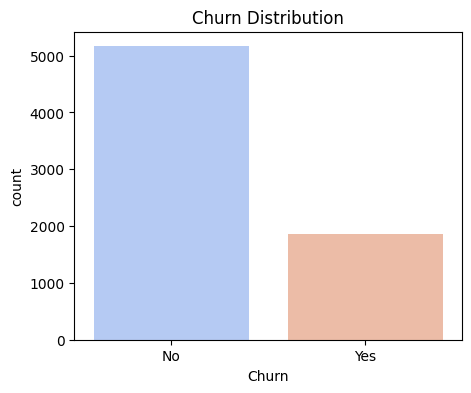

Cleaned dataset shape: (7032, 20)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2.1 — Check hidden blanks in TotalCharges
print("Unique values in TotalCharges (sample):", df['TotalCharges'].unique()[:10])

# Step 2.2 — Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Step 2.3 — Check how many became NaN after conversion
print("\nNumber of NaN in TotalCharges after conversion:", df['TotalCharges'].isna().sum())

# Step 2.4 — Drop rows where TotalCharges is NaN (these are very few)
df = df.dropna(subset=['TotalCharges'])

# Step 2.5 — Drop customerID (not useful)
df = df.drop(columns=['customerID'])

# Step 2.6 — Check class distribution visually
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df, palette='coolwarm')
plt.title('Churn Distribution')
plt.show()

# Step 2.7 — Print updated shape
print("Cleaned dataset shape:", df.shape)


In [ ]:
# Step 3 — Identify numerical and categorical features

# Identify numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("\nCategorical columns:", categorical_cols)


Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [ ]:
# Step 4 — Encode target and preprocess features

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1️⃣ Encode target column
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2️⃣ Split features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# 3️⃣ Create a preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# 4️⃣ Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (5625, 19)
Test shape: (1407, 19)


In [ ]:
# Step 5 — FIXED: Train Logistic Regression Model (cleaned column lists)

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# --- Safety check: remove 'Churn' if it’s in numeric or categorical lists ---
numeric_cols = [c for c in numeric_cols if c != 'Churn']
categorical_cols = [c for c in categorical_cols if c != 'Churn']

print("✅ Columns verified:")
print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

# --- Rebuild the preprocessor just to be safe ---
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# --- Build the Logistic Regression pipeline ---
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# --- Train the model ---
model.fit(X_train, y_train)

print("\n✅ Logistic Regression model trained successfully!")


✅ Columns verified:
Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✅ Logistic Regression model trained successfully!


✅ Model Accuracy: 0.8038

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


🔹 Confusion Matrix:
[[917 116]
 [160 214]]

🔸 ROC AUC Score: 0.8359


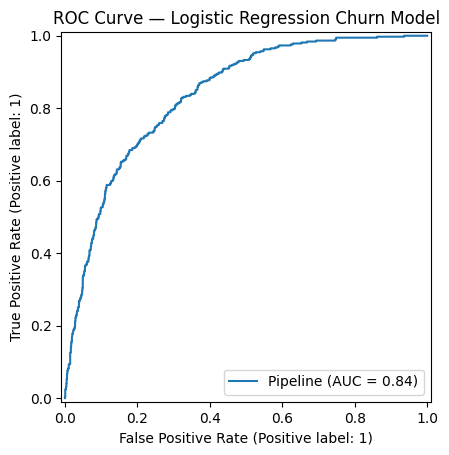

In [ ]:
# Step 6 — Model Evaluation

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# --- Make predictions ---
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# --- Accuracy ---
acc = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {acc:.4f}")

# --- Classification Report ---
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
print("\n🔹 Confusion Matrix:")
print(cm)

# --- ROC Curve ---
roc_auc = roc_auc_score(y_test, y_proba)
print(f"\n🔸 ROC AUC Score: {roc_auc:.4f}")

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve — Logistic Regression Churn Model")
plt.show()


🔝 Top 10 Factors Increasing Churn:
                           Feature  Coefficient
3                     TotalCharges     0.644014
36         Contract_Month-to-month     0.613846
16     InternetService_Fiber optic     0.590184
32                 StreamingTV_Yes     0.191113
43  PaymentMethod_Electronic check     0.180671
35             StreamingMovies_Yes     0.177076
18               OnlineSecurity_No     0.164459
27                  TechSupport_No     0.142949
14               MultipleLines_Yes     0.088164
0                    SeniorCitizen     0.071011

🔻 Top 10 Factors Reducing Churn:
                                 Feature  Coefficient
19    OnlineSecurity_No internet service    -0.283724
17                    InternetService_No    -0.283724
31       StreamingTV_No internet service    -0.283724
25  DeviceProtection_No internet service    -0.283724
12                      MultipleLines_No    -0.293470
39                   PaperlessBilling_No    -0.300387
2                        

<Figure size 1000x600 with 0 Axes>

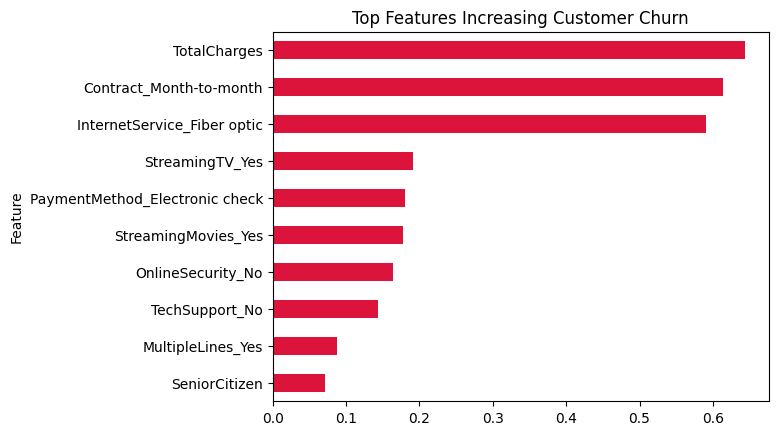

In [ ]:
# Step 7 — Feature Importance (Logistic Regression Coefficients)

import numpy as np

# Get feature names after preprocessing
feature_names = (
    preprocessor.named_transformers_['num'].get_feature_names_out(numeric_cols).tolist() +
    preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
)

# Get model coefficients
coefficients = model.named_steps['classifier'].coef_[0]

# Combine into a DataFrame for readability
feature_importance = (
    pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients
    })
    .sort_values(by='Coefficient', ascending=False)
)

# Display top and bottom contributors
print("🔝 Top 10 Factors Increasing Churn:")
print(feature_importance.head(10))
print("\n🔻 Top 10 Factors Reducing Churn:")
print(feature_importance.tail(10))

# Optional: visualize
plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='barh', x='Feature', y='Coefficient', color='crimson', legend=False)
plt.title("Top Features Increasing Customer Churn")
plt.gca().invert_yaxis()
plt.show()


Top 10 features increasing churn:


,feature,coefficient
0,TotalCharges,0.644014
1,Contract_Month-to-month,0.613846
2,InternetService_Fiber optic,0.590184
3,StreamingTV_Yes,0.191113
4,PaymentMethod_Electronic check,0.180671
5,StreamingMovies_Yes,0.177076
6,OnlineSecurity_No,0.164459
7,TechSupport_No,0.142949
8,MultipleLines_Yes,0.088164
9,SeniorCitizen,0.071011



Top 10 features reducing churn:


,feature,coefficient
44,tenure,-1.352313
43,Contract_Two year,-0.779030
42,InternetService_DSL,-0.616132
41,MonthlyCharges,-0.541006
40,PaperlessBilling_No,-0.300387
39,MultipleLines_No,-0.293470
38,DeviceProtection_No internet service,-0.283724
37,StreamingTV_No internet service,-0.283724
35,OnlineSecurity_No internet service,-0.283724
36,InternetService_No,-0.283724


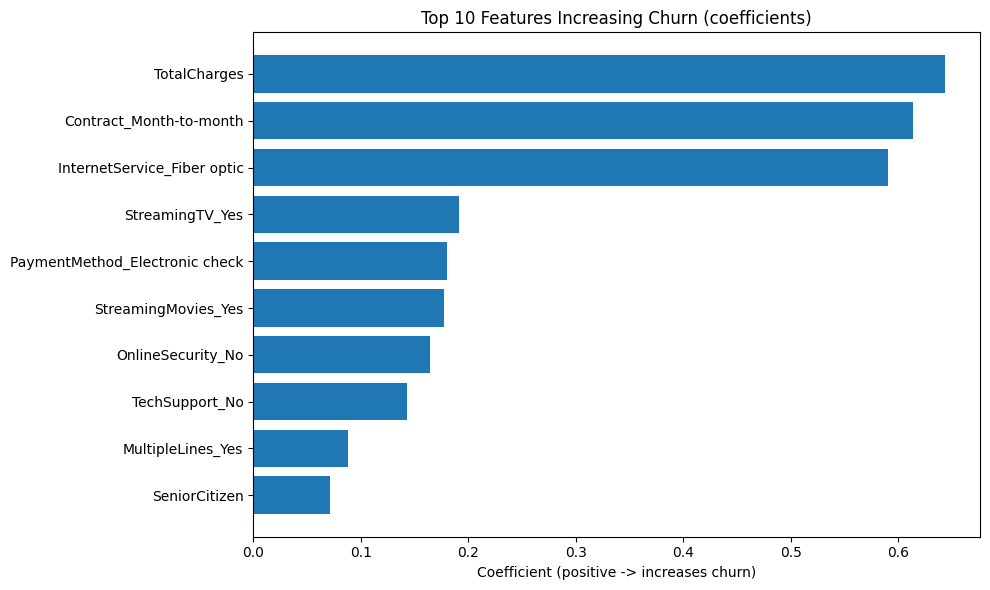

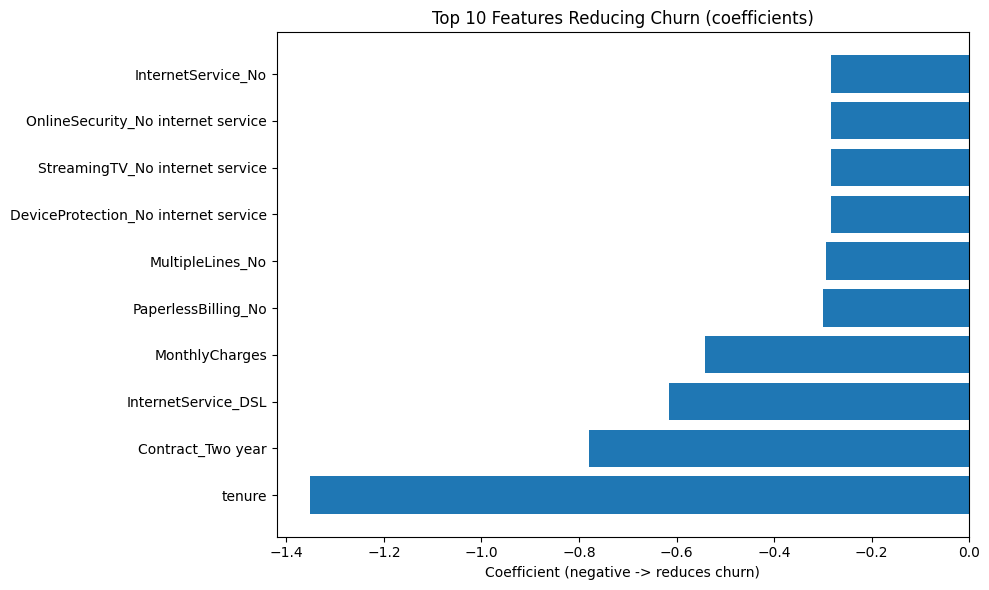

In [ ]:
# Step 8 — Feature importance (coefficients) and visualizations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Get feature names after preprocessing
# numeric feature names (they're the same as numeric_cols)
num_feat_names = numeric_cols

# categorical output feature names from OneHotEncoder
cat_transformer = preprocessor.named_transformers_['cat']
cat_feat_names = cat_transformer.get_feature_names_out(categorical_cols).tolist()

feature_names = num_feat_names + cat_feat_names

# 2) Get coefficients from the trained logistic model
coefs = model.named_steps['classifier'].coef_[0]

# 3) Build DataFrame
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs
}).sort_values(by='coefficient', ascending=False).reset_index(drop=True)

# 4) Show top positive and negative features
top_pos = feat_imp.head(10)
top_neg = feat_imp.tail(10).sort_values(by='coefficient')

print("Top 10 features increasing churn:")
display(top_pos)

print("\nTop 10 features reducing churn:")
display(top_neg)

# 5) Plotting
plt.figure(figsize=(10,6))
plt.barh(top_pos['feature'][::-1], top_pos['coefficient'][::-1])
plt.title('Top 10 Features Increasing Churn (coefficients)')
plt.xlabel('Coefficient (positive -> increases churn)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
plt.barh(top_neg['feature'], top_neg['coefficient'])
plt.title('Top 10 Features Reducing Churn (coefficients)')
plt.xlabel('Coefficient (negative -> reduces churn)')
plt.tight_layout()
plt.show()


In [ ]:
# Step 9 — Predict Churn for New Customers

import pandas as pd

# Example new customers
new_customers = pd.DataFrame({
    'gender': ['Male', 'Female'],
    'SeniorCitizen': [0, 1],
    'Partner': ['Yes', 'No'],
    'Dependents': ['No', 'No'],
    'tenure': [5, 45],
    'PhoneService': ['Yes', 'Yes'],
    'MultipleLines': ['No', 'Yes'],
    'InternetService': ['Fiber optic', 'DSL'],
    'OnlineSecurity': ['No', 'Yes'],
    'OnlineBackup': ['No', 'Yes'],
    'DeviceProtection': ['Yes', 'No'],
    'TechSupport': ['No', 'Yes'],
    'StreamingTV': ['Yes', 'No'],
    'StreamingMovies': ['Yes', 'No'],
    'Contract': ['Month-to-month', 'Two year'],
    'PaperlessBilling': ['Yes', 'No'],
    'PaymentMethod': ['Electronic check', 'Mailed check'],
    'MonthlyCharges': [95.5, 55.2],
    'TotalCharges': [475.0, 2500.0]
})

# Predict churn probabilities
churn_prob = model.predict_proba(new_customers)[:, 1]
predictions = model.predict(new_customers)

# Combine into readable DataFrame
results = new_customers.copy()
results['Churn_Probability'] = churn_prob
results['Predicted_Churn'] = ['Yes' if p == 1 else 'No' for p in predictions]

print("🔮 Predicted Churn for New Customers:")
display(results)


🔮 Predicted Churn for New Customers:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Probability,Predicted_Churn
0,Male,0,Yes,No,5,Yes,No,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.5,475.0,0.752435,Yes
1,Female,1,No,No,45,Yes,Yes,DSL,Yes,Yes,...,Yes,No,No,Two year,No,Mailed check,55.2,2500.0,0.017535,No


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


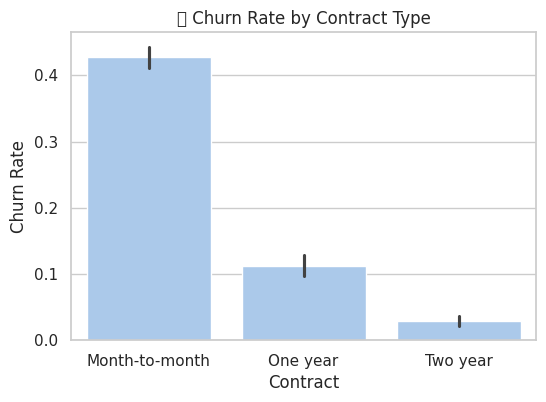

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


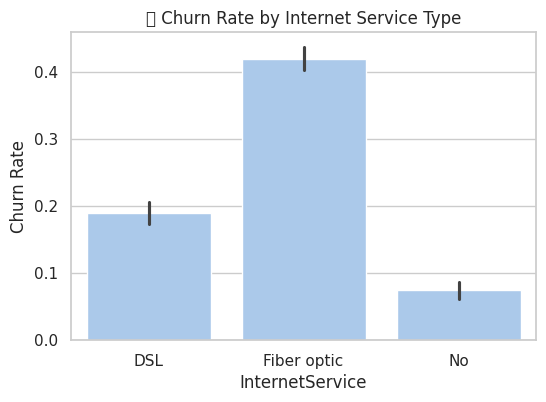

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


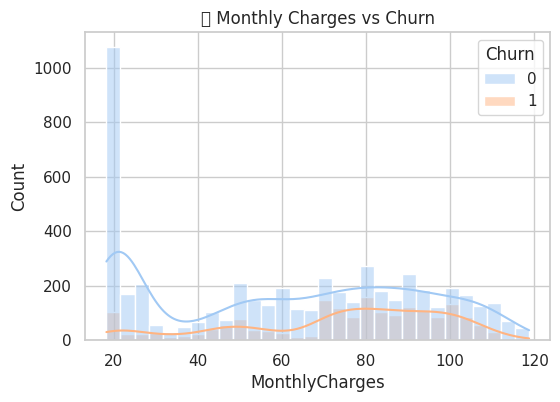

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128338 (\N{CLOCK FACE THREE OCLOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


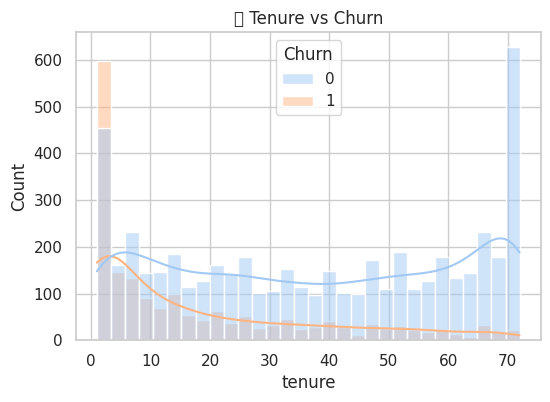

In [ ]:
# Step 10 — Visualization of Key Insights

import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme
sns.set(style="whitegrid", palette="pastel")

# 1️⃣ Churn by Contract Type
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='Contract', y='Churn', estimator=lambda x: sum(x)/len(x))
plt.title('📉 Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.show()

# 2️⃣ Churn by Internet Service Type
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='InternetService', y='Churn', estimator=lambda x: sum(x)/len(x))
plt.title('🌐 Churn Rate by Internet Service Type')
plt.ylabel('Churn Rate')
plt.show()

# 3️⃣ Churn vs Monthly Charges
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True)
plt.title('💰 Monthly Charges vs Churn')
plt.show()

# 4️⃣ Churn vs Tenure
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('🕒 Tenure vs Churn')
plt.show()


In [ ]:
# Step 11 — Save and Load Model for Deployment

import joblib

# Save the trained pipeline (includes preprocessor + Logistic Regression model)
joblib.dump(model, 'churn_prediction_model.pkl')
print("💾 Model saved successfully as 'churn_prediction_model.pkl'")

# To load later (for deployment)
loaded_model = joblib.load('churn_prediction_model.pkl')
print("✅ Model loaded successfully!")

# Test the loaded model on new data (to confirm it works)
test_predictions = loaded_model.predict(new_customers)
print("🔮 Test Predictions from Loaded Model:", test_predictions)


💾 Model saved successfully as 'churn_prediction_model.pkl'
✅ Model loaded successfully!
🔮 Test Predictions from Loaded Model: [1 0]


In [ ]:
# Step 12A — Simple Command-Line Interface for Churn Prediction

import pandas as pd

def predict_churn_interactive(model):
    print("📊 Enter new customer details to predict churn:\n")

    # Collect input interactively
    data = {
        'gender': input("Gender (Male/Female): "),
        'SeniorCitizen': int(input("Senior Citizen (0 = No, 1 = Yes): ")),
        'Partner': input("Has Partner? (Yes/No): "),
        'Dependents': input("Has Dependents? (Yes/No): "),
        'tenure': int(input("Tenure (months): ")),
        'PhoneService': input("Phone Service (Yes/No): "),
        'MultipleLines': input("Multiple Lines (Yes/No/No phone service): "),
        'InternetService': input("Internet Service (DSL/Fiber optic/No): "),
        'OnlineSecurity': input("Online Security (Yes/No/No internet service): "),
        'OnlineBackup': input("Online Backup (Yes/No/No internet service): "),
        'DeviceProtection': input("Device Protection (Yes/No/No internet service): "),
        'TechSupport': input("Tech Support (Yes/No/No internet service): "),
        'StreamingTV': input("Streaming TV (Yes/No/No internet service): "),
        'StreamingMovies': input("Streaming Movies (Yes/No/No internet service): "),
        'Contract': input("Contract Type (Month-to-month/One year/Two year): "),
        'PaperlessBilling': input("Paperless Billing (Yes/No): "),
        'PaymentMethod': input("Payment Method (Electronic check/Mailed check/Bank transfer (automatic)/Credit card (automatic)): "),
        'MonthlyCharges': float(input("Monthly Charges: ")),
        'TotalCharges': float(input("Total Charges: "))
    }

    # Convert to DataFrame
    customer_df = pd.DataFrame([data])

    # Predict churn probability
    prob = model.predict_proba(customer_df)[0][1]
    pred = model.predict(customer_df)[0]

    print("\n🔮 Prediction Result:")
    print(f"Predicted Churn: {'Yes' if pred == 1 else 'No'}")
    print(f"Churn Probability: {prob:.2f}")

# Run the function
predict_churn_interactive(model)


📊 Enter new customer details to predict churn:

Gender (Male/Female): male
Senior Citizen (0 = No, 1 = Yes): 1
Has Partner? (Yes/No): no
Has Dependents? (Yes/No): no
Tenure (months): 3
Phone Service (Yes/No): no
